In [1]:
# ============================================
# Credit Card Fraud Detection
# Algorithm: Decision Tree
# ============================================

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    balanced_accuracy_score, matthews_corrcoef
)

from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")

In [2]:
# ============================================
# 2. Load Dataset
# ============================================

df = pd.read_csv("creditcard.csv")

print("\n===========================================")
print("DATASET INFORMATION")
print("===========================================")
print("Original Dataset Shape:", df.shape)


DATASET INFORMATION
Original Dataset Shape: (284807, 31)


In [3]:
# ============================================
# 3. Handle Duplicate Values
# ============================================

duplicate_count = df.duplicated().sum()

print("\nDuplicate Rows Found:", duplicate_count)

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)


Duplicate Rows Found: 1081
Dataset Shape After Removing Duplicates: (283726, 31)


In [4]:
# ============================================
# 4. Dataset Info
# ============================================

print("\n===========================================")
print("DATASET STRUCTURE")
print("===========================================")
df.info()


DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 


CLASS DISTRIBUTION
Class
0    283253
1       473
Name: count, dtype: int64


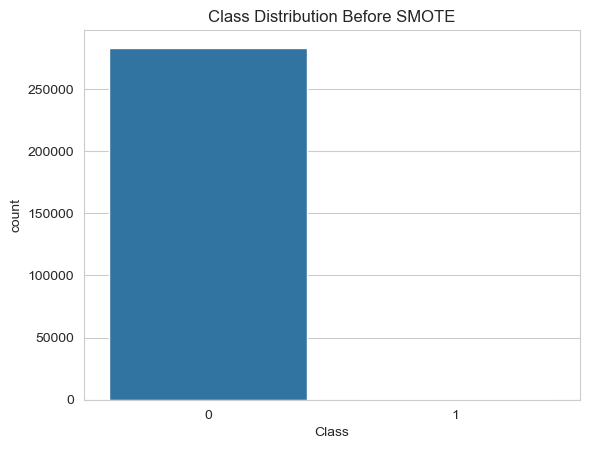

In [5]:
# ============================================
# 5. Class Distribution
# ============================================

print("\n===========================================")
print("CLASS DISTRIBUTION")
print("===========================================")
print(df["Class"].value_counts())

sns.countplot(x="Class", data=df)
plt.title("Class Distribution Before SMOTE")
plt.show()

In [6]:
# ============================================
# 6. Missing Values
# ============================================

print("\n===========================================")
print("MISSING VALUES")
print("===========================================")
print(df.isnull().sum())


MISSING VALUES
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# ============================================
# 7. Feature Scaling
# ============================================

scaler = StandardScaler()

df["Amount"] = scaler.fit_transform(df[["Amount"]])
df["Time"] = scaler.fit_transform(df[["Time"]])

In [8]:
# ============================================
# 8. Features and Labels
# ============================================

X = df.drop("Class", axis=1)
y = df["Class"]

In [9]:
# ============================================
# 9. Train-Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===========================================")
print("DATA SPLIT")
print("===========================================")
print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)


DATA SPLIT
Training Set: (226980, 30)
Testing Set : (56746, 30)


In [10]:
# ============================================
# 10. SMOTE
# ============================================

print("\n===========================================")
print("CLASS BALANCING USING SMOTE")
print("===========================================")

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

print("\nNew Training Set Size:", X_train_smote.shape[0])


CLASS BALANCING USING SMOTE
Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64

New Training Set Size: 453204


In [11]:
# ============================================
# 11. Hyperparameter Tuning
# ============================================

print("\n===========================================")
print("HYPERPARAMETER TUNING")
print("===========================================")

param_grid = {
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid_search.best_params_)

model = grid_search.best_estimator_
model.fit(X_train_smote, y_train_smote)


HYPERPARAMETER TUNING
Best Parameters: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2}


,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
# ============================================
# 12. Prediction
# ============================================

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]